# Bayesian Sampling Methods: A Practical Tutorial


---
## Background Concepts

### Bayes' Theorem

All samplers in this notebook target the **posterior distribution**:

$$p(\theta \mid D) = \frac{p(D \mid \theta)\; p(\theta)}{p(D)}$$

| Term | Name | Meaning |
|------|------|---------|
| $p(\theta \mid D)$ | **Posterior** | What we want: the probability of parameters $\theta$ given data $D$ |
| $p(D \mid \theta)$ | **Likelihood** $\mathcal{L}(\theta)$ | How probable is the data if $\theta$ is the true parameter? |
| $p(\theta)$ | **Prior** | What we believed before seeing data |
| $p(D) = Z$ | **Evidence** | A normalising constant; equal to $\int \mathcal{L}(\theta)\,p(\theta)\,d\theta$ |

For **parameter estimation** (most of this notebook) you can ignore $Z$ — it's just a constant. For **model comparison** (Nautilus, dynesty) $\log Z$ is exactly what you need.

---

### Proposals

Every MCMC sampler needs a way to suggest the next point to visit — this is the **proposal**. A good proposal should:

1. Be easy to sample from
2. Propose moves that are accepted often (not too bold)
3. Not be so timid that the chain barely moves (high autocorrelation)

Different samplers solve this differently:

| Sampler | How proposals are generated |
|---------|-----------------------------|
| **emcee** | Uses other walkers in the ensemble as a reference: $\theta^\star = \theta_j + z(\theta_k - \theta_j)$, where $z \sim g(z) \propto 1/\sqrt{z}$. No tuning needed. |
| **NUTS** | Simulates Hamiltonian dynamics using the gradient $\nabla \log p(\theta \mid D)$ to propose long, curved trajectories correlated with the posterior geometry. |
| **pocoMC** | Trains a normalizing flow on current particles to map the posterior to a Gaussian, then proposes in that easy space. |
| **Nautilus / dynesty** | Propose uniformly inside bounding regions (ellipsoids / neural networks) that contain the current live points. |

---

### Effective Sample Size (ESS)

Raw MCMC samples are **correlated** — consecutive steps are similar because each new point depends on the previous one. ESS measures how many *independent* samples the chain is worth:

$$\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{\infty} \rho_k}$$

where $N$ is the total number of samples and $\rho_k$ is the autocorrelation at lag $k$. Equivalently, ESS $\approx N / \tau$ where $\tau$ is the **integrated autocorrelation time**.

- **ESS = N**: every sample is independent (ideal, unachievable in practice)
- **ESS ≪ N**: high autocorrelation; rare with good proposals, common with bad ones
- A useful figure of merit is **ESS/second** — how many independent samples do you get per unit compute time?




## Installation

Run the cell below once to install all required packages.

In [ ]:
# Uncomment and run if packages are not already installed
# !pip install emcee corner numpyro jax pocomc nautilus-sampler dynesty


---
## Shared Setup

Run this cell first. It generates the two datasets used throughout the notebook.

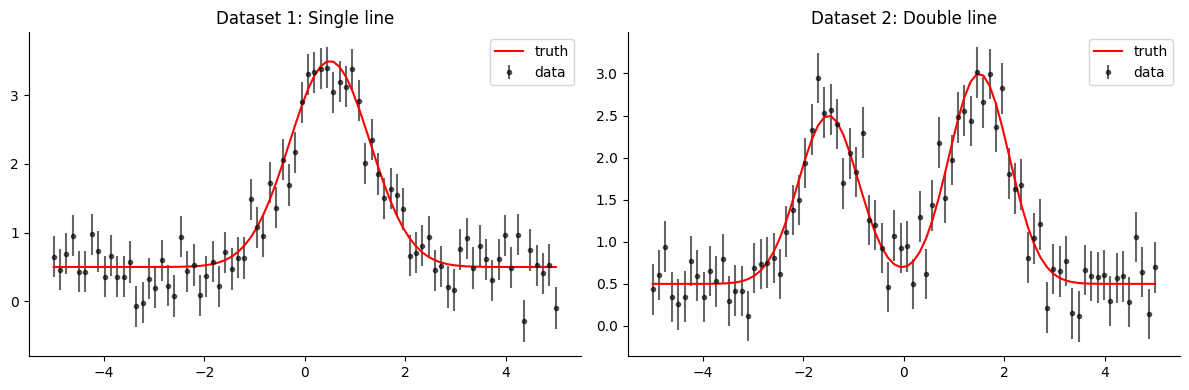

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time

mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

np.random.seed(42)

# Spectral axis
x = np.linspace(-5, 5, 80)
yerr = 0.3

# --- Dataset 1: Single emission line (Levels 1-3) ---
A_true, mu_true, sigma_true, b_true = 3.0, 0.5, 0.8, 0.5
y_true = A_true * np.exp(-0.5 * ((x - mu_true) / sigma_true)**2) + b_true
y_obs  = y_true + np.random.normal(0, yerr, len(x))

# --- Dataset 2: Two emission lines (Levels 4-5) ---
y_true2 = (2.0 * np.exp(-0.5 * ((x - (-1.5)) / 0.6)**2) +
           2.5 * np.exp(-0.5 * ((x -   1.5)  / 0.6)**2) + 0.5)
y_obs2  = y_true2 + np.random.normal(0, yerr, len(x))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(x, y_obs,  yerr=yerr, fmt='k.', alpha=0.6, label='data')
axes[0].plot(x, y_true, 'r-', label='truth')
axes[0].set_title('Dataset 1: Single line'); axes[0].legend()
axes[1].errorbar(x, y_obs2, yerr=yerr, fmt='k.', alpha=0.6, label='data')
axes[1].plot(x, y_true2, 'r-', label='truth')
axes[1].set_title('Dataset 2: Double line'); axes[1].legend()
plt.tight_layout()
plt.show()

# Accumulate runtimes across cells for the final comparison table
runtimes = {}


---
## emcee
**Smooth, unimodal posterior · 3 parameters · No gradients needed**

**Model:** Single Gaussian with fixed background.  
**Parameters:** amplitude `A`, mean `μ`, width `σ`

**Sampler:**  affine-invariant ensemble sampler proposed by Goodman & Weare (2010). The key departure from traditional MCMC is that it runs many chains simultaneously — called walkers — and uses their collective positions to make proposals, rather than relying on a fixed proposal distribution.

**Why emcee?** This is the simplest Bayesian problem: smooth likelihood, few parameters, no multimodality. emcee's ensemble of "stretch-move" walkers is the right starting point — it requires no gradients, no tuning, and produces intuitive chain / corner diagnostics. It's the workhorse of low-dimensional astrophysical inference.

**What to watch for:**
- Trace plots: do walkers mix well after burn-in?
- Autocorrelation time: how many steps until an independent sample?
- Corner plot: are the marginals unimodal and well-constrained?

**Limitation preview:** emcee's random-walk proposals scale poorly to higher dimensions and some cases of strongly correlated parameters


100%|██████████| 2000/2000 [00:00<00:00, 2882.13it/s]


Autocorrelation times: A=31.1, μ=33.9, σ=30.6
Using discard=500, thin=1


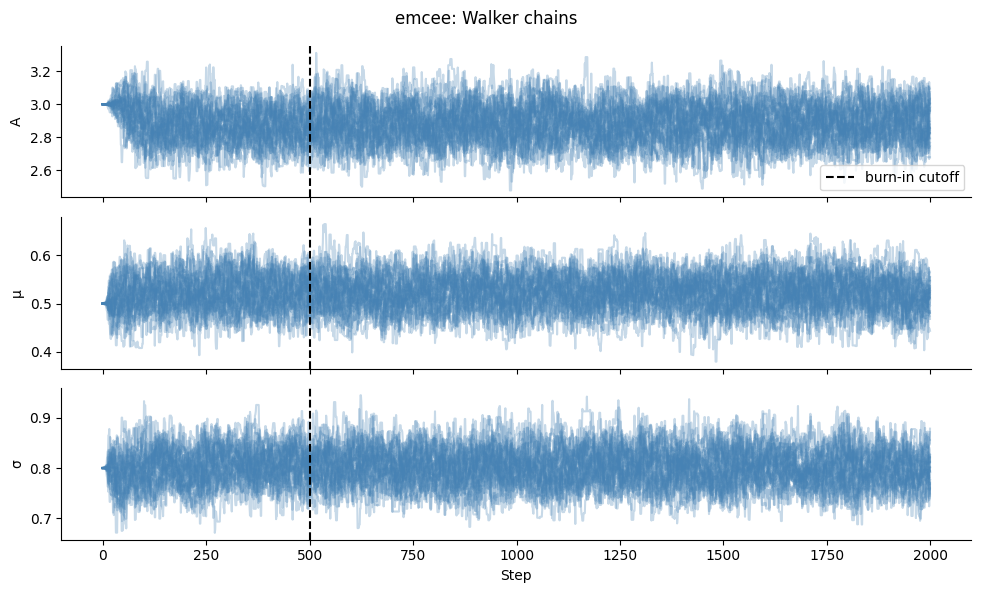

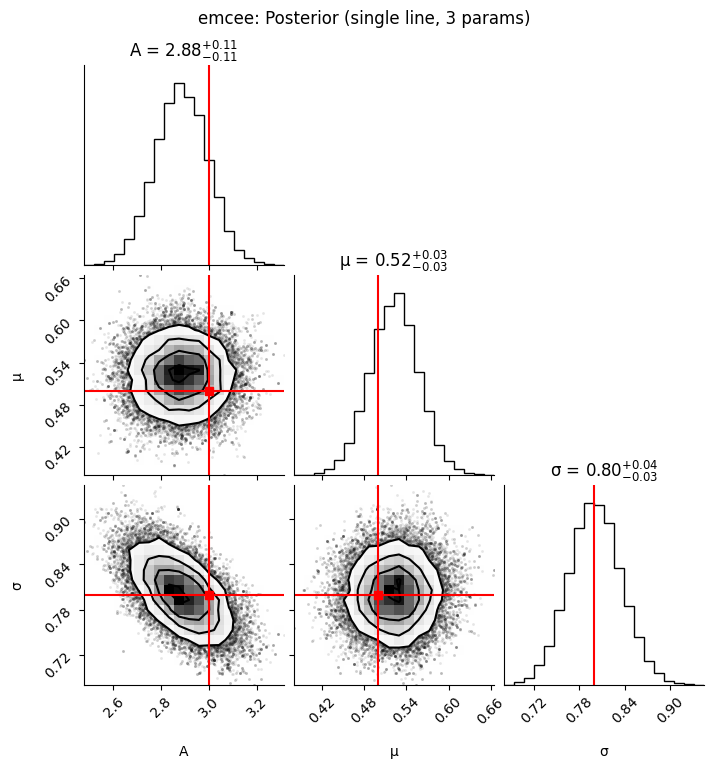

Median estimates: A=2.88, μ=0.52, σ=0.80
Runtime: 0.7s  |  n samples ≈ 48000 (post-thinning)


In [58]:
import emcee
import corner

def log_likelihood_l1(params):
    A, mu, sigma = params
    if sigma <= 0 or A <= 0:
        return -np.inf
    # Note: background b_true is fixed in Level 1; it becomes a free parameter in Levels 2+
    model = A * np.exp(-0.5 * ((x - mu) / sigma)**2) + b_true
    return -0.5 * np.sum(((y_obs - model) / yerr)**2)

def log_prior_l1(params):
    A, mu, sigma = params
    if 0 < A < 10 and -5 < mu < 5 and 0.1 < sigma < 3:
        return 0.0
    return -np.inf

def log_prob_l1(params):
    lp = log_prior_l1(params)
    return lp + log_likelihood_l1(params) if np.isfinite(lp) else -np.inf

#nwalkers should be *at least* 2*ndim but more is often better for exploring complex posteriors and ensuring good mixing. Here we use 32 walkers for a 3D parameter space, which is a common choice.
ndim, nwalkers = 3, 32
# Tiny perturbation ensures all walkers start safely inside the prior bounds
p0 = np.array([3.0, 0.5, 0.8]) + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_l1)
t0 = time.perf_counter()
sampler.run_mcmc(p0, 2000, progress=True)
runtimes['emcee'] = time.perf_counter() - t0

# --- Autocorrelation / convergence ---
tau = sampler.get_autocorr_time()
#thin = max(1, int(np.max(tau) / 2))
thin = 1
labels = ["A", "μ", "σ"]
print("Autocorrelation times: " + ", ".join(f"{l}={t:.1f}" for l, t in zip(labels, tau)))
print(f"Using discard=500, thin={thin}")

# --- Chain plot ---
fig, axes = plt.subplots(3, figsize=(10, 6), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(sampler.get_chain()[:, :, i], alpha=0.3, color='steelblue')
    ax.axvline(500, color='k', linestyle='--', label='burn-in cutoff')
    ax.set_ylabel(label)
axes[0].legend(); axes[-1].set_xlabel("Step")
plt.suptitle("emcee: Walker chains")
plt.tight_layout()
plt.show()

# --- Corner plot (with thinning to reduce autocorrelation) ---
samples_emcee = sampler.get_chain(discard=500, thin=thin, flat=True)
fig = corner.corner(
    samples_emcee, labels=labels,
    truths=[A_true, mu_true, sigma_true],
    truth_color='red', show_titles=True
)
plt.suptitle("emcee: Posterior (single line, 3 params)", y=1.02)
plt.show()

print(f"Median estimates: A={np.median(samples_emcee[:,0]):.2f}, "
      f"μ={np.median(samples_emcee[:,1]):.2f}, "
      f"σ={np.median(samples_emcee[:,2]):.2f}")
print(f"Runtime: {runtimes['emcee']:.1f}s  |  n samples ≈ {len(samples_emcee)} (post-thinning)")


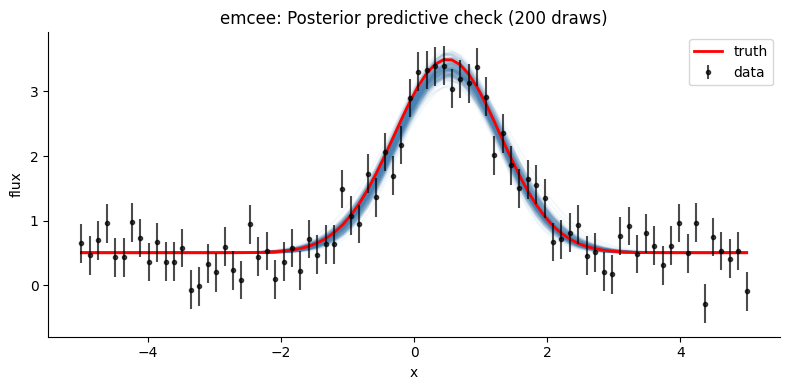

In [7]:
# --- Posterior predictive check ---
# Draw random samples from the posterior and overlay model curves on the data.
# If the shaded region covers the data well, the model is a good fit.
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(x, y_obs, yerr=yerr, fmt='k.', alpha=0.7, label='data', zorder=5)
rng = np.random.default_rng(0)
idx = rng.choice(len(samples_emcee), size=min(200, len(samples_emcee)), replace=False)
for A, mu, sigma in samples_emcee[idx]:
    ax.plot(x, A * np.exp(-0.5 * ((x - mu) / sigma)**2) + b_true,
            alpha=0.05, color='steelblue')
ax.plot(x, y_true, 'r-', lw=2, label='truth')
ax.set_title("emcee: Posterior predictive check (200 draws)")
ax.set_xlabel("x"); ax.set_ylabel("flux")
ax.legend()
plt.tight_layout()
plt.show()


---
##  NUTS via NumPyro
**Correlated parameters · 4 parameters · Gradient-powered**

**Model:** Single Gaussian + free background.  
**Parameters:** `A`, `μ`, `σ`, `b` (amplitude and background are correlated)

**Why upgrade to NUTS?** Adding a free background creates correlations between `A` and `b`. emcee's stretch moves make axis-aligned proposals that cut diagonally across the correlation ridge, wasting many steps. NUTS (the No-U-Turn Sampler) uses gradients of the log-posterior to propose long, curved trajectories that follow the ridge — dramatically improving the number of effective samples per second.

**What to watch for:**
- `r_hat ≈ 1.0` for all parameters (convergence)
- Effective Sample Size (ESS) per second — we'll compare directly against emcee below
- The A–b correlation visible in the corner plot

**Trade-off:** NUTS requires a differentiable likelihood (here via JAX). If your likelihood is a black-box simulator, you can't use gradient-based methods.


/Users/asemenaite/miniconda3/envs/mcenv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
sample: 100%|██████████| 2500/2500 [00:00<00:00, 2593.32it/s, 7 steps of size 5.16e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A      2.91      0.11      2.91      2.72      3.08   1182.69      1.00
         b      0.47      0.05      0.47      0.40      0.55   1679.51      1.00
        mu      0.52      0.04      0.52      0.47      0.58   2077.88      1.00
     sigma      0.81      0.04      0.81      0.75      0.88   1229.76      1.00

Number of divergences: 0
Runtime: 3.2s


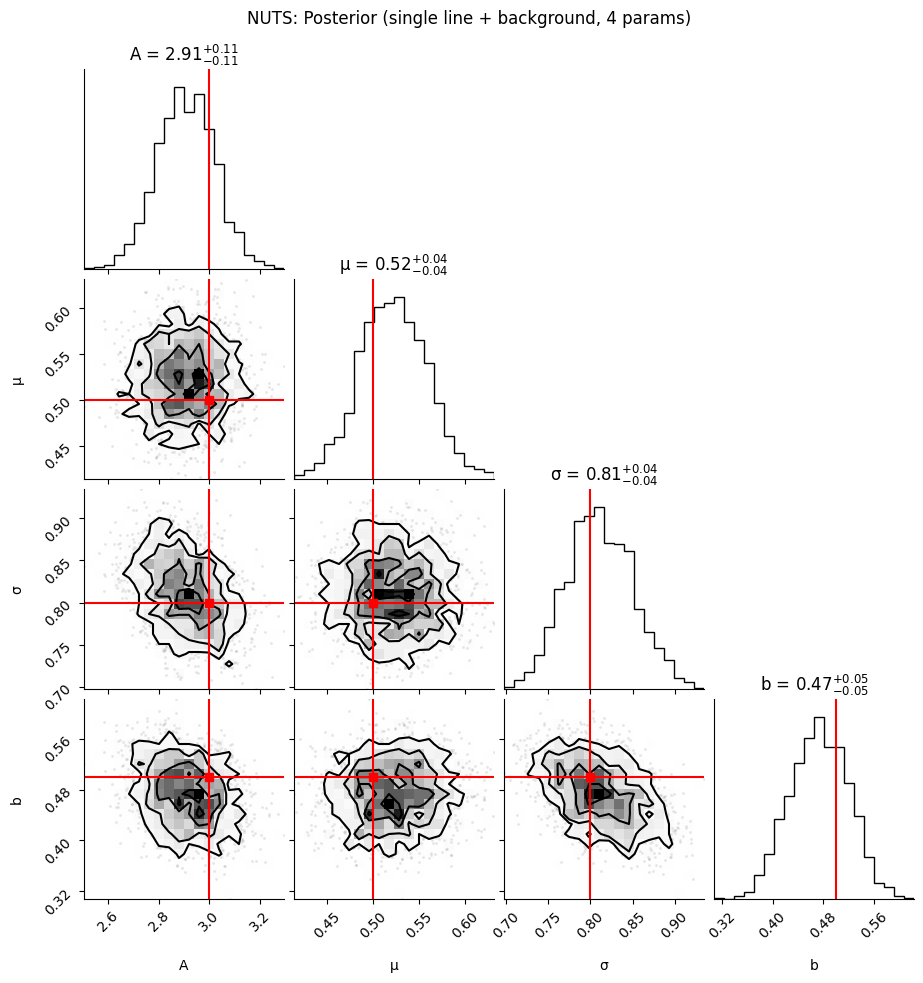

In [16]:
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

x_jax = jnp.array(x)
y_jax = jnp.array(y_obs)

def model_l2():
    A     = numpyro.sample("A",     dist.Uniform(0.0, 10.0))
    mu    = numpyro.sample("mu",    dist.Uniform(-5.0, 5.0))
    sigma = numpyro.sample("sigma", dist.Uniform(0.1, 3.0))
    b     = numpyro.sample("b",     dist.Uniform(-1.0, 3.0))
    pred  = A * jnp.exp(-0.5 * ((x_jax - mu) / sigma)**2) + b
    numpyro.sample("obs", dist.Normal(pred, yerr), obs=y_jax)

kernel = NUTS(model_l2)
#Warmup is used to tune:
#The step size ε: how large a leap each HMC step takes (tuned via dual averaging to hit a target acceptance rate, default ~0.8)
#The mass matrix M: a diagonal or dense preconditioning matrix that rescales parameters so they all have similar variance, making the trajectory more efficient
mcmc   = MCMC(kernel, num_warmup=500, num_samples=2000, progress_bar=True)
t0 = time.perf_counter()
mcmc.run(random.PRNGKey(0))
runtimes['nuts'] = time.perf_counter() - t0
mcmc.print_summary()  # shows ESS and r_hat per parameter
print(f"Runtime: {runtimes['nuts']:.1f}s")

samples_nuts = {k: np.array(v) for k, v in mcmc.get_samples().items()}

# --- Corner plot ---
nuts_array = np.column_stack([samples_nuts[k] for k in ["A", "mu", "sigma", "b"]])
fig = corner.corner(
    nuts_array, labels=["A", "μ", "σ", "b"],
    truths=[A_true, mu_true, sigma_true, b_true],
    truth_color='red', show_titles=True
)
plt.suptitle("NUTS: Posterior (single line + background, 4 params)", y=1.02)
plt.show()


### Head-to-head: emcee vs NUTS on the same 4-parameter problem



In [74]:
# --- Run emcee on the SAME 4-param problem for a fair comparison ---
def log_prob_4p(params):
    A, mu, sigma, b = params
    if sigma <= 0 or A <= 0:
        return -np.inf
    if not (0 < A < 10 and -5 < mu < 5 and 0.1 < sigma < 3 and -1 < b < 3):
        return -np.inf
    model = A * np.exp(-0.5 * ((x - mu) / sigma)**2) + b
    return -0.5 * np.sum(((y_obs - model) / yerr)**2)

ndim4, nwalkers4 = 4, 32
p0_4 = np.array([3.0, 0.5, 0.8, 0.5]) + 1e-4 * np.random.randn(nwalkers4, ndim4)
sampler_4p = emcee.EnsembleSampler(nwalkers4, ndim4, log_prob_4p)

t0 = time.perf_counter()
sampler_4p.run_mcmc(p0_4, 2000, progress=True)
emcee_4p_time = time.perf_counter() - t0

tau_4p = sampler_4p.get_autocorr_time(quiet=True)
thin_4p = max(1, int(np.max(tau_4p) / 2))
#thin_4p = 1
samples_emcee_4p = sampler_4p.get_chain(discard=500, thin=thin_4p, flat=True)
emcee_ess = (2000*nwalkers4) / int(np.max(tau_4p))
emcee_ess_per_s = emcee_ess / emcee_4p_time

# For NUTS, samples after warmup are ~independent (low autocorrelation by design).
# Use num_samples as a conservative ESS estimate.
nuts_ess = 2000
nuts_ess_per_s = nuts_ess / runtimes['nuts']

'''
# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
samplers_cmp = ['emcee (4p)', 'NUTS (4p)']
colors_cmp = ['steelblue', 'darkorange']

axes[0].bar(samplers_cmp, [emcee_4p_time, runtimes['nuts']], color=colors_cmp)
axes[0].set_ylabel('seconds'); axes[0].set_title('Wall-clock time')

axes[1].bar(samplers_cmp, [emcee_ess, nuts_ess], color=colors_cmp)
axes[1].set_ylabel('samples'); axes[1].set_title('Effective sample size')

axes[2].bar(samplers_cmp, [emcee_ess_per_s, nuts_ess_per_s], color=colors_cmp)
axes[2].set_ylabel('ESS / sec'); axes[2].set_title('Sampling efficiency')

plt.suptitle('emcee vs NUTS on the same 4-param model', fontweight='bold')
plt.tight_layout()
plt.show()
'''

print(f"emcee: ~{emcee_ess} effective samples in {emcee_4p_time:.1f}s → {emcee_ess_per_s:.0f} ESS/s")
print(f"NUTS:  ~{nuts_ess} effective samples in {runtimes['nuts']:.1f}s → {nuts_ess_per_s:.0f} ESS/s")



100%|██████████| 2000/2000 [00:00<00:00, 3233.56it/s]
N/50 = 40;
tau: [45.25382325 38.67859649 37.16186158 42.36377972]


emcee: ~1422.2222222222222 effective samples in 0.6s → 2283 ESS/s
NUTS:  ~2000 effective samples in 3.2s → 626 ESS/s


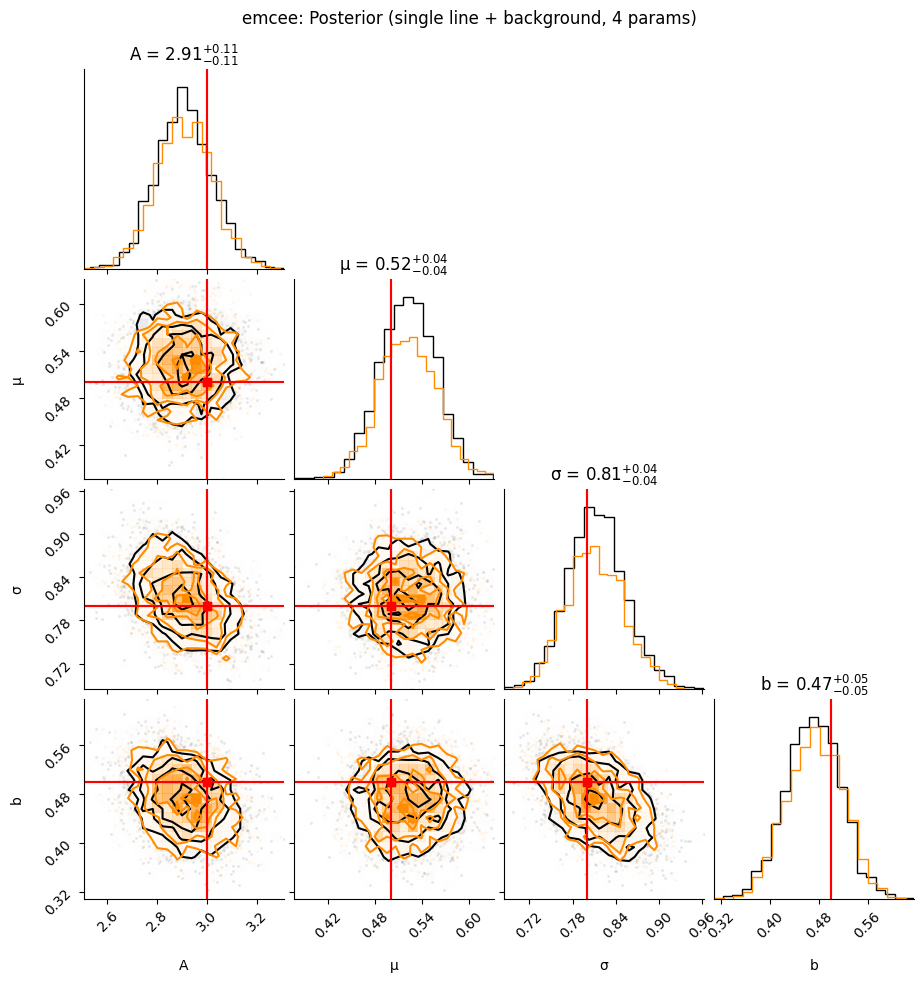

In [75]:
# --- Corner plot ---

fig = corner.corner(
    samples_emcee_4p, labels=["A", "mu", "sigma", "b"],
    truths=[A_true, mu_true, sigma_true, b_true],
    truth_color='red', show_titles=True
)

corner2 = corner.corner(
    nuts_array, labels=["A", "μ", "σ", "b"], color='darkorange',
    truths=[A_true, mu_true, sigma_true, b_true],
    truth_color='red', show_titles=True, fig=fig,
)

plt.suptitle("emcee: Posterior (single line + background, 4 params)", y=1.02)
plt.show()


---
## pocoMC
**Non-Gaussian (banana) posterior · 4 parameters · Flow preconditioning**


**Sampler** Based on Sequential Monte Carlo (SMC) which works by morphing from prior to posterior through intermediate distributions described by: π_β(θ) ∝ p(θ) · p(data | θ)^β (where at β=0 π_β(θ) is the prior and at β=1 π_β(θ) respresents the posterior). Allows to handle multi-modal distributions better. Pure SMC still requires a proposal but in pocoMC normalising flows are used to transform the posterior into a Gaussian which is easy to sample. 

The full pocoMC loop looks like:

1. Start with prior samples as particles
2. Find the next β by some criterion (typically how much the weights degenerate)
3. Reweight and resample particles
4. Train a normalizing flow on current particles
5. Run MCMC in the flow-transformed space to move particles
6. Map particles back to original space
7. Repeat from step 2 until β = 1

**Model:** Single Gaussian + background, but now with `log σ` **and** sparse, noisy data.  
**Parameters:** `A`, `μ`, `log σ`, `b`

**Why a new dataset?** With the 80-point, low-noise Dataset 1, both `A` and `σ` are pinned down independently — no reparameterisation can create curvature in a posterior that's already nearly Gaussian. To see genuine banana geometry we need a regime where the data primarily constrain the *total line flux* `F ∝ A·σ` rather than `A` and `σ` separately. This happens naturally in low-S/N or sparsely-sampled spectra — a common situation in real observations.

Under the log-σ parameterisation the flux degeneracy `A·exp(log σ) ≈ const` traces an **exponential curve** in the (`A`, `log σ`) plane — the banana visible in the corner plot below.

**Why pocoMC over NUTS?** Two scenarios motivate pocoMC:
1. **Black-box likelihoods** — If your forward model is a compiled simulation with no autodiff support, gradient-based samplers like NUTS are simply not an option. pocoMC only needs the log-likelihood *value*.
2. **Nasty geometry** — pocoMC's normalizing flow *learns* the posterior shape and preconditions the sampling automatically — no manual reparameterisation required.

**What to watch for:**
- The clear banana in the `A`–`log σ` marginal (contrast with the elliptical `A`–`σ` marginals from Levels 1–2)
- pocoMC samples are weighted; `posterior()` returns importance weights

**Trade-off:** pocoMC is slower wall-clock per effective sample than NUTS when gradients *are* available. It's the right tool when they aren't.

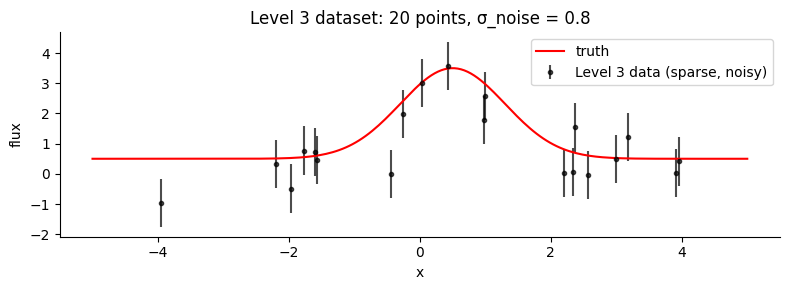

Iter: 27it [00:36,  1.37s/it, beta=1, calls=36096, ESS=3992, logZ=-15.2, logP=-15.6, acc=0.86, steps=3, eff=0.832]     


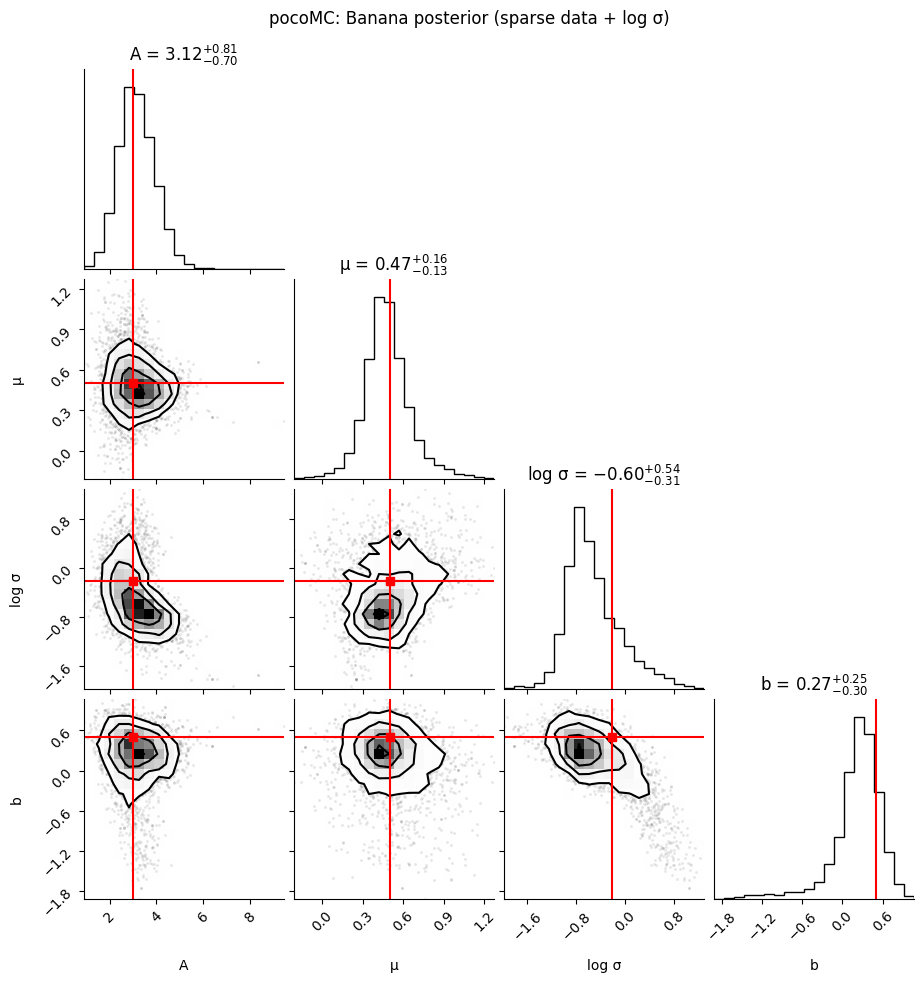

Recovered σ (median exp): 0.547  (truth: 0.8)
Runtime: 36.9s


In [77]:
import pocomc
from scipy.stats import uniform

# --- Level 3 dataset: sparse, noisy observation ---
# With only ~20 points and high noise, the data constrain total flux (A·σ)
# much better than A and σ individually → banana in (A, log σ) space.
rng_l3 = np.random.default_rng(7)
x_l3 = np.sort(rng_l3.uniform(-4, 4, 20))
yerr_l3 = 0.8
y_true_l3 = A_true * np.exp(-0.5 * ((x_l3 - mu_true) / sigma_true)**2) + b_true
y_obs_l3  = y_true_l3 + rng_l3.normal(0, yerr_l3, len(x_l3))

fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(x_l3, y_obs_l3, yerr=yerr_l3, fmt='k.', alpha=0.7, label='Level 3 data (sparse, noisy)')
xfine = np.linspace(-5, 5, 200)
ax.plot(xfine, A_true * np.exp(-0.5 * ((xfine - mu_true) / sigma_true)**2) + b_true,
        'r-', label='truth')
ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('flux')
ax.set_title('Level 3 dataset: 20 points, σ_noise = 0.8')
plt.tight_layout(); plt.show()

def log_likelihood_l3(params):
    A, mu, log_sigma, b = params
    sigma = np.exp(log_sigma)
    model = A * np.exp(-0.5 * ((x_l3 - mu) / sigma)**2) + b
    return -0.5 * np.sum(((y_obs_l3 - model) / yerr_l3)**2)

prior_l3 = pocomc.Prior([
    uniform(loc=0.1, scale=9.9),   # A
    uniform(loc=-5,  scale=10),    # mu
    uniform(loc=-2,  scale=4),     # log_sigma  (exp range: ~0.14 to 7.4)
    uniform(loc=-2,  scale=5),     # b
])

sampler_poco = pocomc.Sampler(
    prior_l3,
    log_likelihood_l3,
    random_state=42,
)
t0 = time.perf_counter()
sampler_poco.run(progress=True)
runtimes['pocomc'] = time.perf_counter() - t0
samples_poco, log_w, log_l, log_p = sampler_poco.posterior()

# --- Corner plot ---
fig = corner.corner(
    samples_poco,
    labels=["A", "μ", "log σ", "b"],
    truths=[A_true, mu_true, np.log(sigma_true), b_true],
    truth_color='red', show_titles=True
)
plt.suptitle("pocoMC: Banana posterior (sparse data + log σ)", y=1.02)
plt.show()

print(f"Recovered σ (median exp): {np.exp(np.median(samples_poco[:,2])):.3f}  "
      f"(truth: {sigma_true})")
print(f"Runtime: {runtimes['pocomc']:.1f}s")

---
##  Nautilus

**Sampler:**

Nautilus trains a neural network to approximate the posterior, uses that approximation as a proposal distribution, draws samples from it, and then corrects for the approximation error using importance weights.

Nautilus builds the approximation iteratively because you don't know the posterior before you start:

1. Draw initial samples from the prior
2. Evaluate the true likelihood at those points
3. Train a neural network to predict whether a point is in a high-posterior region
4. Use the network to propose new samples concentrated in high-posterior regions
5. Evaluate the true likelihood at proposed points
6. Add these to the training set and retrain (not every step)
7. Repeat until the approximation stabilises
8. Draw a final large batch from the trained network and compute importance weights

**Model comparison via Bayes factor · 4 vs 7 parameters · Neural importance sampling**

**Models compared:**
- **M1:** Single Gaussian on the two-line dataset (wrong model)
- **M2:** Two Gaussians on the two-line dataset (correct model)

**Why nested sampling?** All MCMC samplers (emcee, NUTS, pocoMC) answer: *"Given this model, what are the parameter values?"* They do **not** answer: *"Which model explains the data better?"* For that you need the Bayesian evidence $\log Z = \log \int \mathcal{L}(\theta)\,\pi(\theta)\,d\theta$, which is a by-product of nested sampling but essentially impossible to extract from MCMC chains.

Nautilus uses neural networks to learn an efficient importance sampling distribution — it avoids wasting likelihood evaluations in low-probability regions and scales well to moderate dimensions.

**What to watch for:**
- The Bayes factor $\ln B = \log Z_{M2} - \log Z_{M1}$: values > 5 are "strong evidence"
- Nautilus converges in far fewer likelihood calls than classic nested sampling

**Trade-off:** Nautilus can underperform when the posterior is strongly multimodal with well-separated modes — its neural network may not discover all of them. That's where dynesty shines.


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 18600    | N/A    | 10079 | -184.31  
M1 log Z = -184.31  (24.8s)
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 38     | 1        | 8        | 26200    | N/A    | 10005 | -58.00   
M2 log Z = -58.00  (61.8s)

log Bayes Factor (M2 vs M1) = 126.31
→ Strong evidence for the two-line model

ESS: 10005 / 26200 raw samples


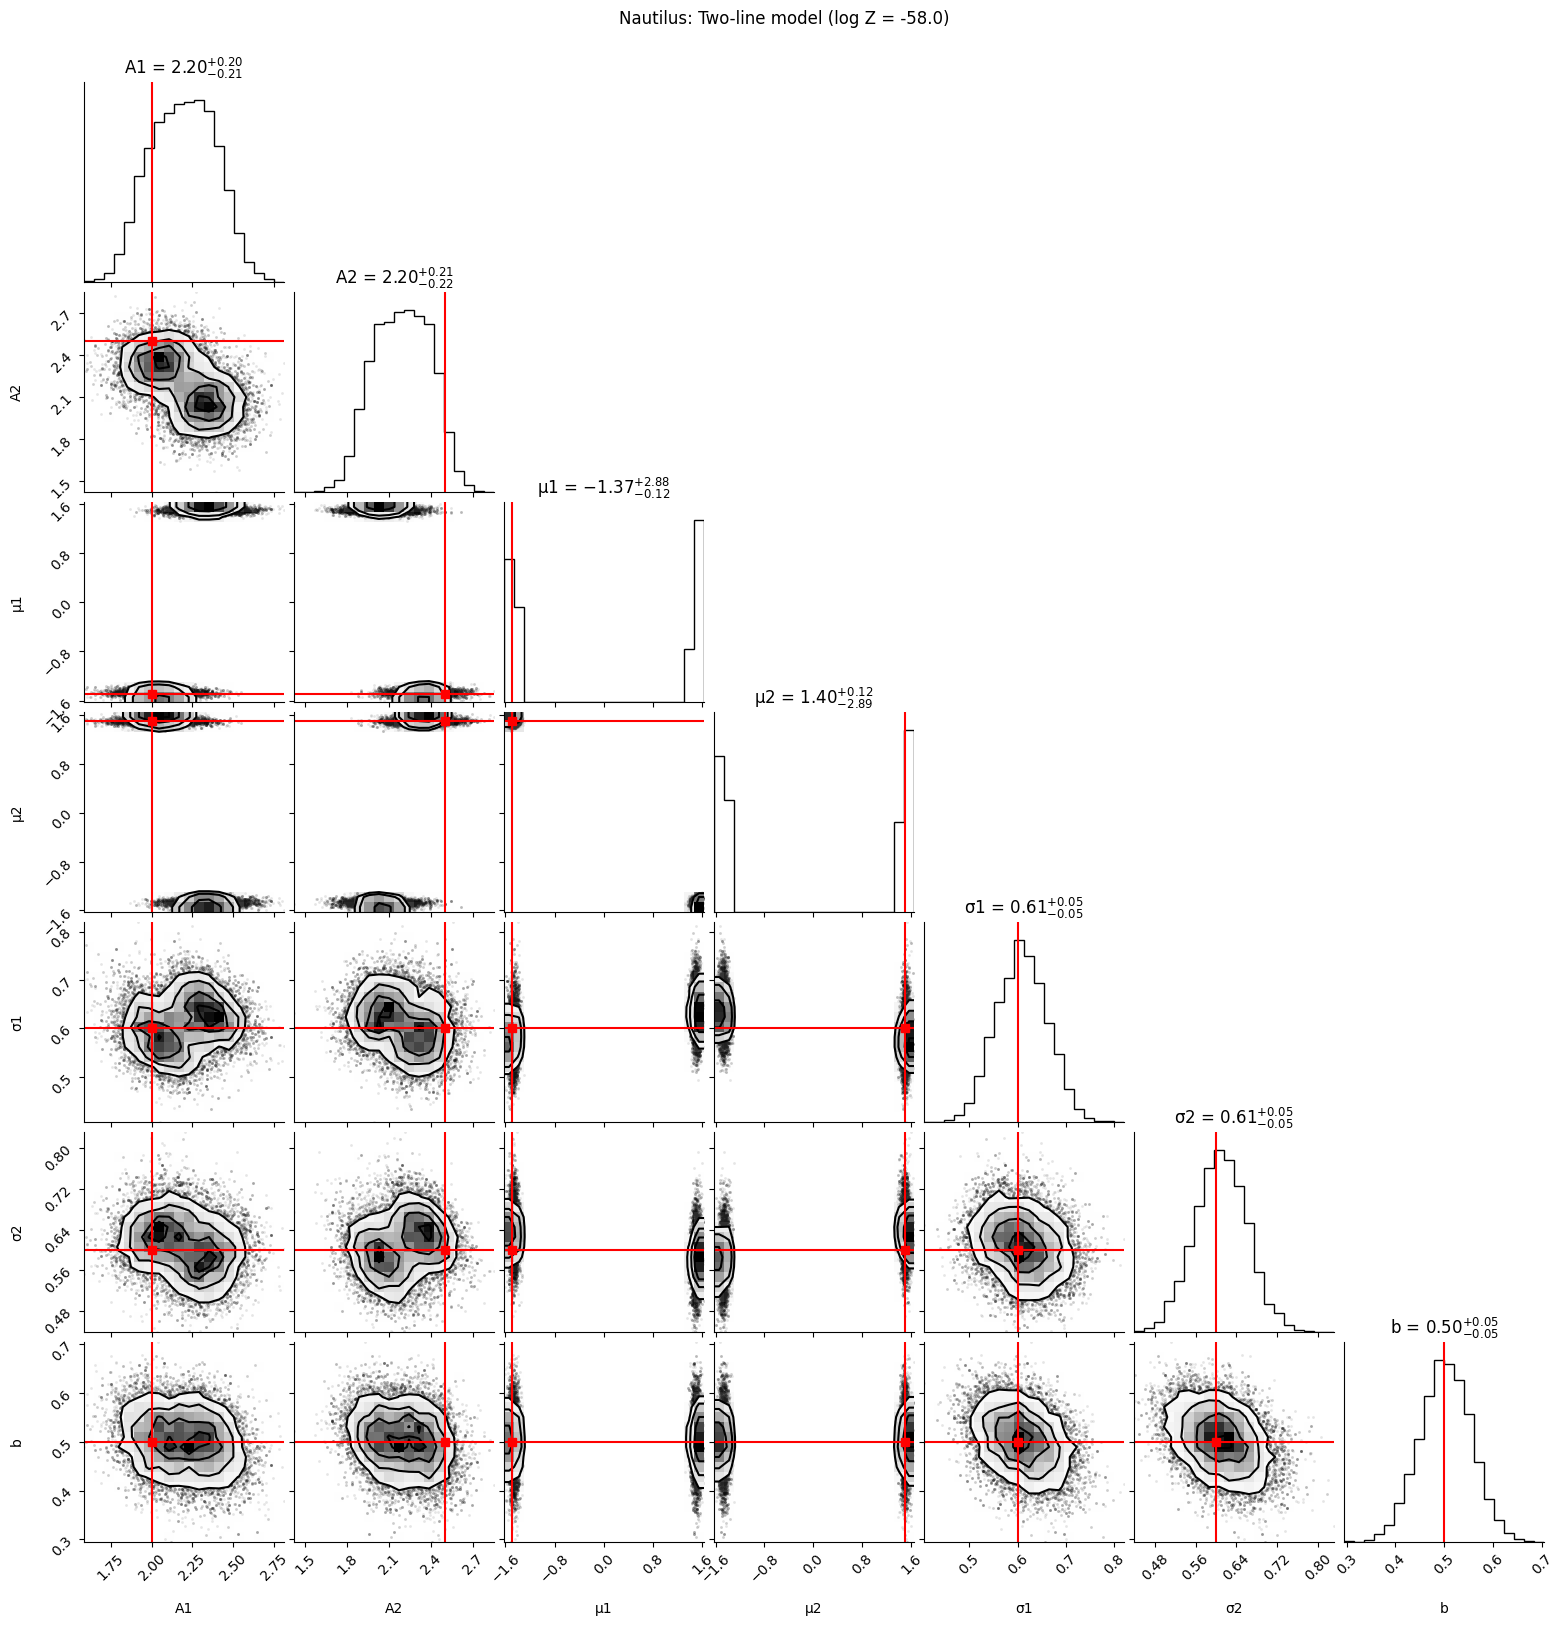

In [55]:
from nautilus import Prior, Sampler as NautilusSampler

# ---- Model 1: Single Gaussian on two-line data ----
prior_m1 = Prior()
prior_m1.add_parameter('A',     dist=(0, 10))
prior_m1.add_parameter('mu',    dist=(-5, 5))
prior_m1.add_parameter('sigma', dist=(0.1, 3))
prior_m1.add_parameter('b',     dist=(-1, 3))

def like_m1(p):
    m = p['A'] * np.exp(-0.5 * ((x - p['mu']) / p['sigma'])**2) + p['b']
    return -0.5 * np.sum(((y_obs2 - m) / yerr)**2)

sampler_m1 = NautilusSampler(prior_m1, like_m1, n_live=400)
t0 = time.perf_counter()
sampler_m1.run(verbose=True)
samples_m1, _, log_z_m1 = sampler_m1.posterior()
log_z_m1 = sampler_m1.log_z
print(f"M1 log Z = {log_z_m1:.2f}  ({time.perf_counter()-t0:.1f}s)")

# ---- Model 2: Two Gaussians ----
prior_m2 = Prior()
for name in ['A1', 'A2']:    prior_m2.add_parameter(name, dist=(0, 10))
for name in ['mu1', 'mu2']:  prior_m2.add_parameter(name, dist=(-5, 5))
for name in ['s1', 's2']:    prior_m2.add_parameter(name, dist=(0.1, 3))
prior_m2.add_parameter('b',  dist=(-1, 3))

def like_m2(p):
    m = (p['A1'] * np.exp(-0.5 * ((x - p['mu1']) / p['s1'])**2) +
         p['A2'] * np.exp(-0.5 * ((x - p['mu2']) / p['s2'])**2) + p['b'])
    return -0.5 * np.sum(((y_obs2 - m) / yerr)**2)

sampler_m2 = NautilusSampler(prior_m2, like_m2, n_live=400)
t0 = time.perf_counter()
sampler_m2.run(verbose=True)
samples_m2, logw_m2, log_z_m2 = sampler_m2.posterior()
log_z_m2 = sampler_m2.log_z
runtimes['nautilus'] = time.perf_counter() - t0
print(f"M2 log Z = {log_z_m2:.2f}  ({runtimes['nautilus']:.1f}s)")

# ---- Bayes Factor ----
ln_bf = log_z_m2 - log_z_m1
print(f"\nlog Bayes Factor (M2 vs M1) = {ln_bf:.2f}")
if ln_bf > 5:
    print("→ Strong evidence for the two-line model")
elif ln_bf > 2.5:
    print("→ Moderate evidence for the two-line model")
else:
    print("→ Weak or no preference")

# ---- Resample to equally-weighted samples for corner ----
w = np.exp(logw_m2)
w /= w.sum()
ess = float(1.0 / np.sum(w**2))
print(f"\nESS: {ess:.0f} / {len(w)} raw samples")
rng_ns = np.random.default_rng(0)
idx = rng_ns.choice(len(samples_m2), size=len(samples_m2), p=w, replace=True)
samples_m2_eq = samples_m2[idx]

fig = corner.corner(
    samples_m2_eq,
    labels=["A1", "A2", "μ1", "μ2", "σ1", "σ2", "b"],
    truths=[2.0, 2.5, -1.5, 1.5, 0.6, 0.6, 0.5],
    truth_color='red',
    show_titles=True
)
plt.suptitle(f"Nautilus: Two-line model (log Z = {log_z_m2:.1f})", y=1.02)
plt.show()

### Failure demo: emcee on the bimodal problem

To illustrate how MCMC handles label-switching, let's run emcee on the same symmetric two-line problem and see what happens.


You must install the tqdm library to use progress indicators with emcee


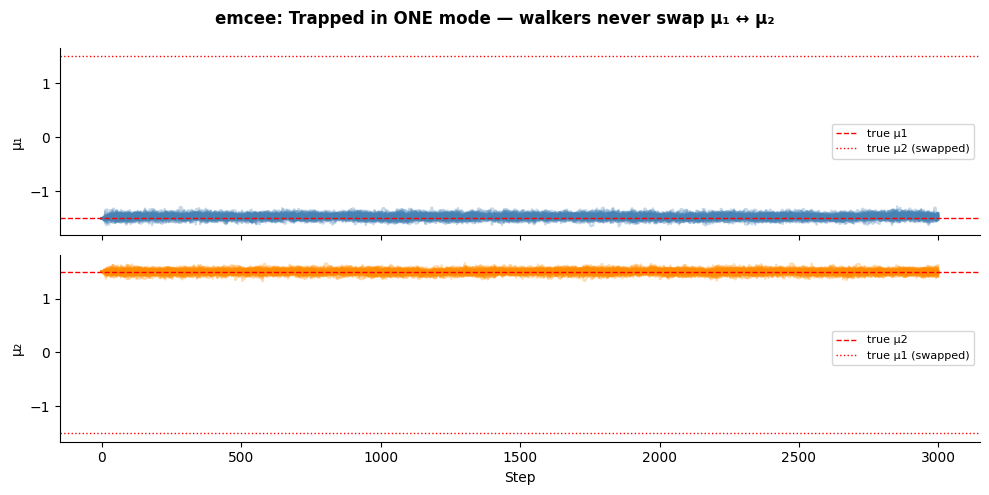

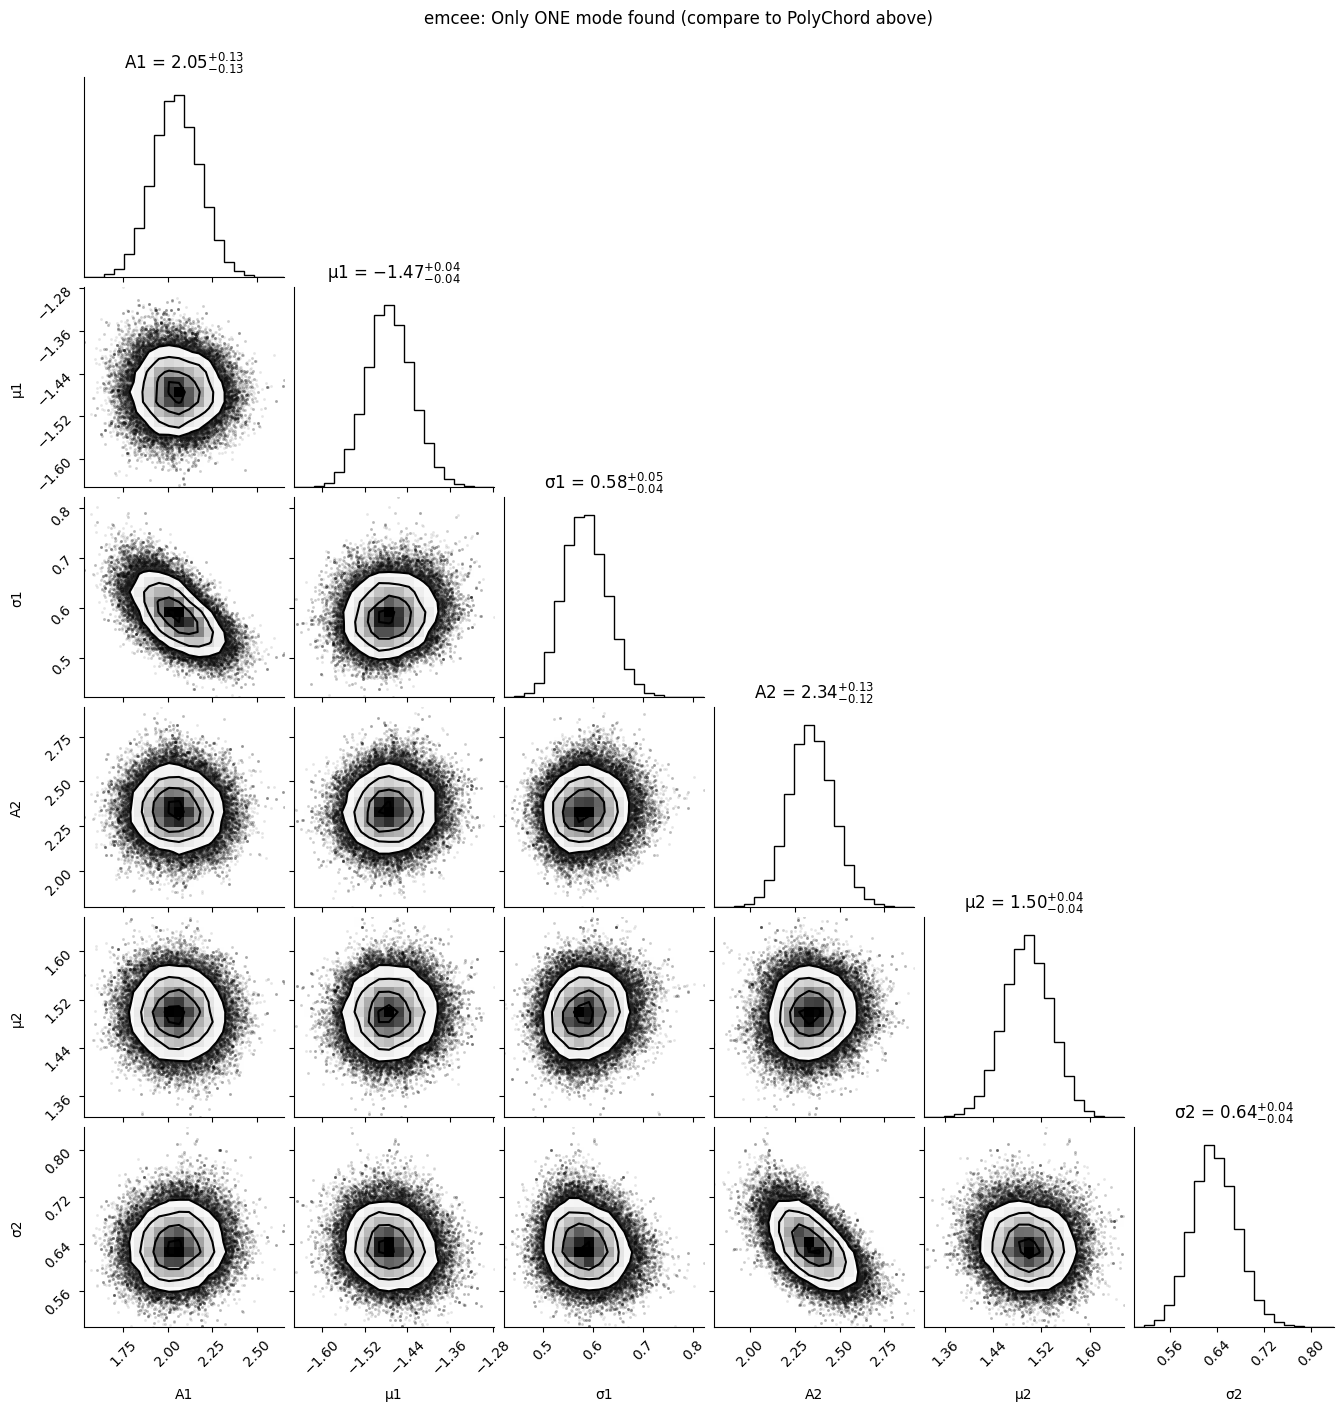

emcee found only the mode near its starting point.
PolyChord's nested sampling mapped BOTH modes and returned a reliable log Z.


In [13]:
# --- emcee on the bimodal (label-switching) problem ---

def log_prob_bimodal(params):
    A1, mu1, s1, A2, mu2, s2 = params
    if s1 <= 0 or s2 <= 0 or A1 <= 0 or A2 <= 0:
        return -np.inf
    if not (0 < A1 < 5 and -5 < mu1 < 5 and 0.1 < s1 < 2 and
            0 < A2 < 5 and -5 < mu2 < 5 and 0.1 < s2 < 2):
        return -np.inf
    m = (A1 * np.exp(-0.5 * ((x - mu1) / s1)**2) +
         A2 * np.exp(-0.5 * ((x - mu2) / s2)**2) + 0.5)
    return -0.5 * np.sum(((y_obs2 - m) / yerr)**2)

ndim_bi, nwalkers_bi = 6, 48
# Initialise walkers near ONE of the two modes (line 1 left, line 2 right)
p0_bi = np.array([2.0, -1.5, 0.6, 2.5, 1.5, 0.6]) + 1e-3 * np.random.randn(nwalkers_bi, ndim_bi)

sampler_bi = emcee.EnsembleSampler(nwalkers_bi, ndim_bi, log_prob_bimodal)
sampler_bi.run_mcmc(p0_bi, 3000, progress=True)

# --- Show that emcee is TRAPPED in one mode ---
chains = sampler_bi.get_chain()  # shape (steps, walkers, ndim)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Plot mu1 and mu2 chains — if emcee found both modes, we'd see walkers
# swap between mu1≈-1.5 and mu1≈+1.5 (and vice versa for mu2).
axes[0].plot(chains[:, :, 1], alpha=0.3, color='steelblue')
axes[0].axhline(-1.5, color='red', ls='--', lw=1, label='true μ1')
axes[0].axhline( 1.5, color='red', ls=':',  lw=1, label='true μ2 (swapped)')
axes[0].set_ylabel('μ₁'); axes[0].legend(fontsize=8)

axes[1].plot(chains[:, :, 4], alpha=0.3, color='darkorange')
axes[1].axhline( 1.5, color='red', ls='--', lw=1, label='true μ2')
axes[1].axhline(-1.5, color='red', ls=':',  lw=1, label='true μ1 (swapped)')
axes[1].set_ylabel('μ₂'); axes[1].set_xlabel('Step'); axes[1].legend(fontsize=8)

plt.suptitle("emcee: Trapped in ONE mode — walkers never swap μ₁ ↔ μ₂",
             fontweight='bold')
plt.tight_layout()
plt.show()

samples_bi = sampler_bi.get_chain(discard=500, flat=True)
fig = corner.corner(
    samples_bi,
    labels=["A1", "μ1", "σ1", "A2", "μ2", "σ2"],
    show_titles=True
)
plt.suptitle("emcee: Only ONE mode found — label-switching is unresolved", y=1.02)
plt.show()
print("emcee found only the mode near its starting point.\n"
      "Nested samplers (dynesty, Nautilus) map both modes via systematic contour shrinkage.")


---
## dynesty

**General-purpose nested sampling · 7 parameters · Dynamic bounding ellipsoids**

**Model:** Two Gaussians on the two-line dataset (same M2 as Level 4).  
**Parameters:** `A1`, `A2`, `μ1`, `μ2`, `σ1`, `σ2`, `b`

**Why dynesty?** dynesty is a widely used nested sampler in astrophysics. It uses bounding ellipsoids to efficiently propose new live points, with a dynamic allocation strategy that concentrates likelihood evaluations where the evidence integrand changes fastest.

**What to watch for:**
- The run plot shows exactly how nested sampling works: live points compress inward iteration by iteration
- Dynamic allocation means more likelihood evaluations are spent on the high-evidence region
- Compare log Z with Nautilus (Level 4) — both nested samplers should agree


4532it [00:52, 21.00it/s, batch: 0 | bound: 453 | nc: 77 | ncall: 395901 | eff(%):  1.143 | loglstar:   -inf < -184.516 <    inf | logz: -196.449 +/-  0.147 | dlogz: 115.184 >  0.010]  /Users/asemenaite/miniconda3/envs/mcenv2/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4562it [00:53, 28.51it/s, batch: 0 | bound: 469 | nc: 1335 | ncall: 412021 | eff(%):  1.106 | loglstar:   -inf < -183.603 <    inf | logz: -195.474 +/-  0.147 | dlogz: 114.145 >  0.010]/Users/asemenaite/miniconda3/envs/mcenv2/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for th


log Z = -57.91 ± 0.14  (310.0s)


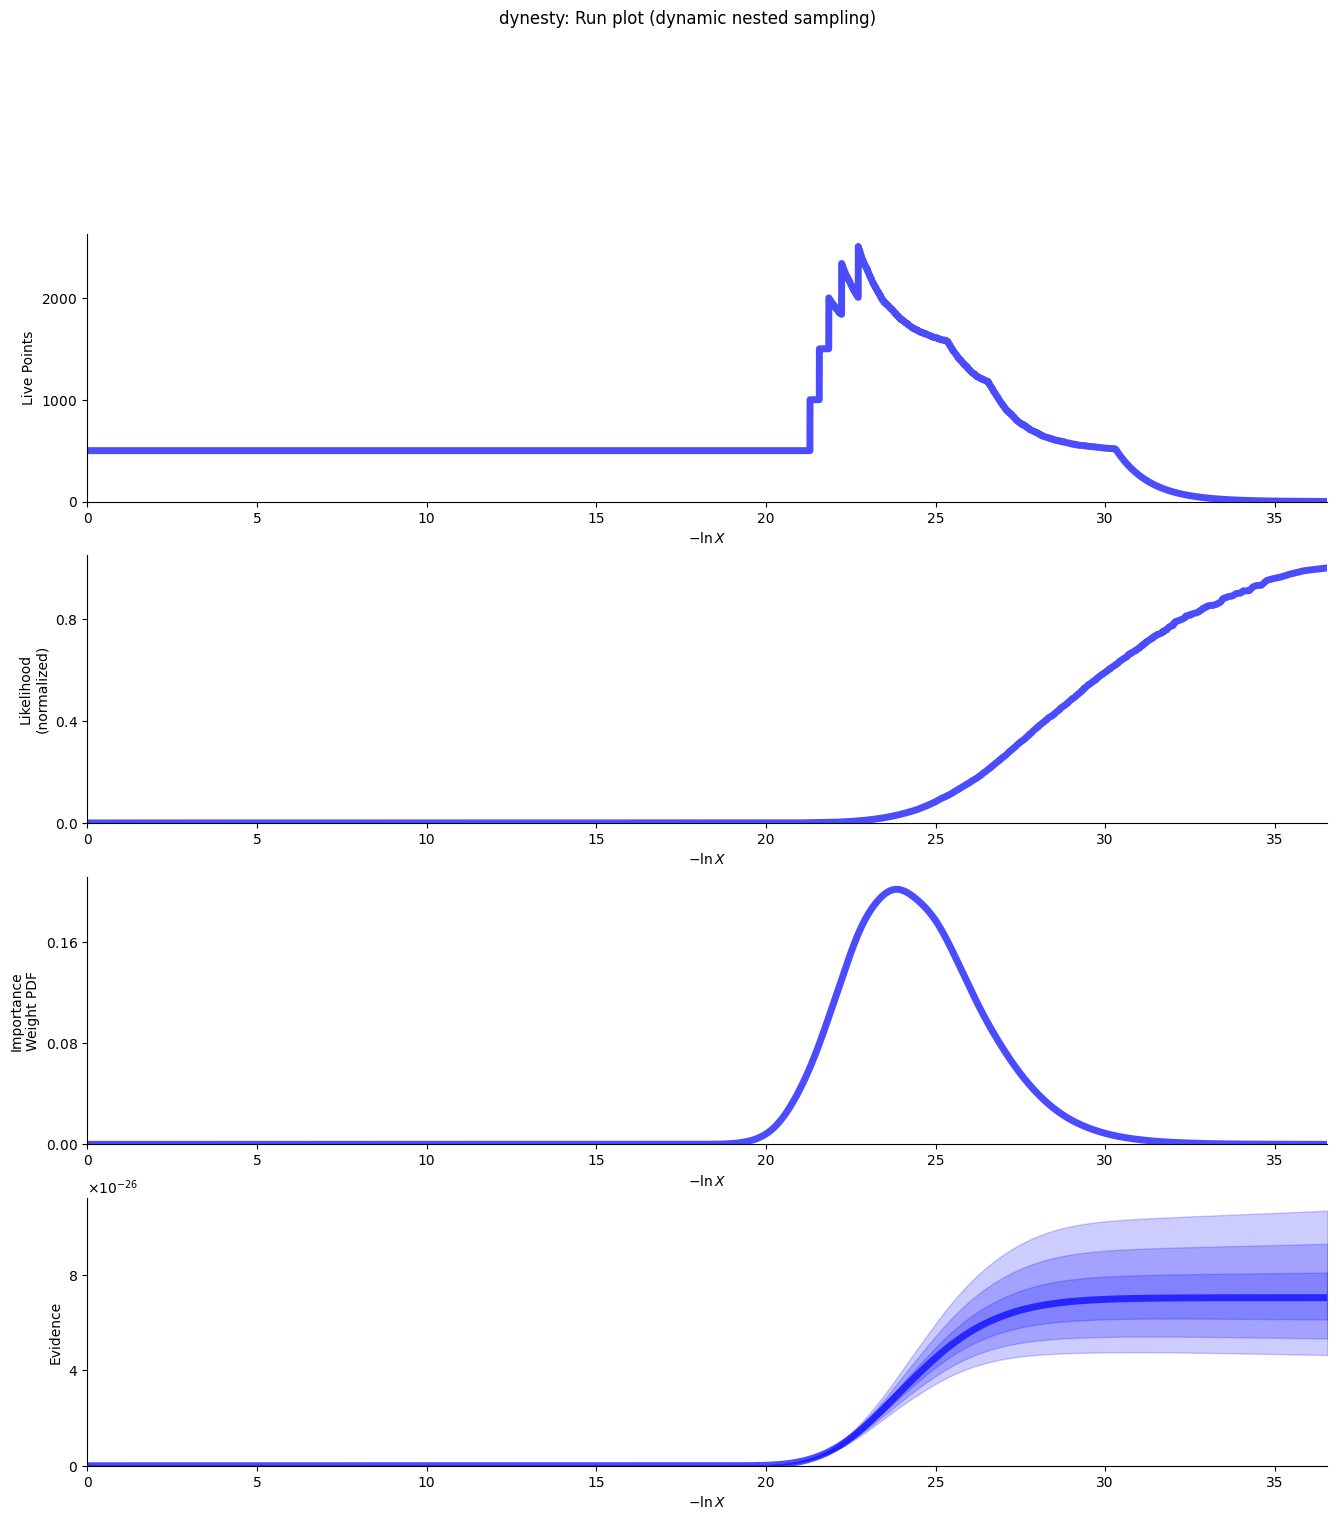

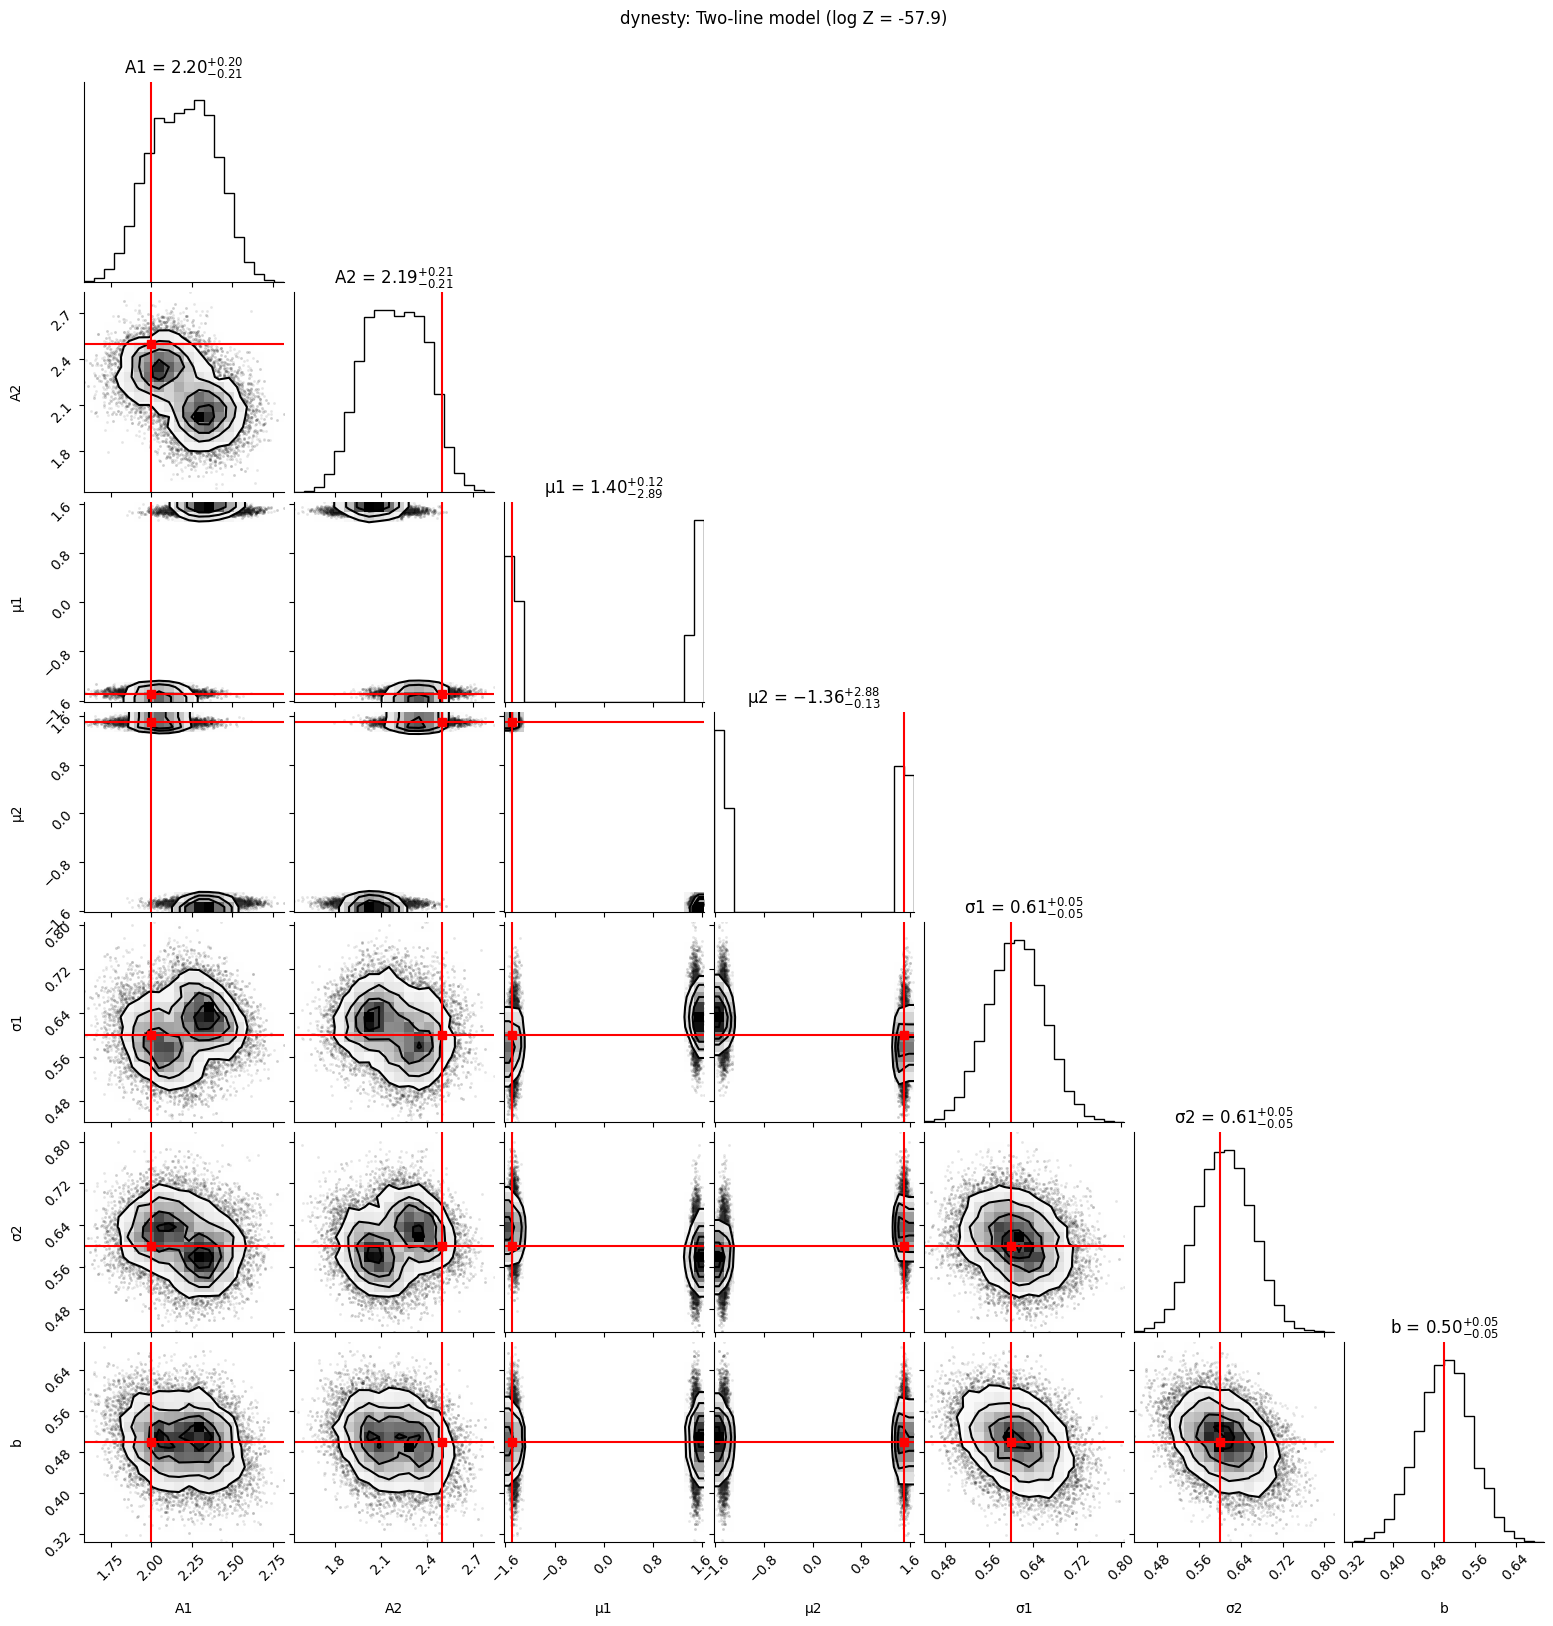


Compare evidence estimates:
  dynesty   log Z = -57.91 ± 0.14
  Nautilus  log Z = -58.00


In [81]:
import dynesty

# Prior transform: unit hypercube → physical parameters
def prior_transform_dynesty(u):
    p = np.empty(7)
    p[0] = 10.0 * u[0]            # A1 in [0, 10]
    p[1] = 10.0 * u[1]            # A2 in [0, 10]
    p[2] = -5.0 + 10.0 * u[2]    # mu1 in [-5, 5]
    p[3] = -5.0 + 10.0 * u[3]    # mu2 in [-5, 5]
    p[4] = 0.1 + 2.9 * u[4]      # s1 in [0.1, 3]
    p[5] = 0.1 + 2.9 * u[5]      # s2 in [0.1, 3]
    p[6] = -1.0 + 4.0 * u[6]     # b in [-1, 3]
    return p

def log_likelihood_dynesty(params):
    A1, A2, mu1, mu2, s1, s2, b = params
    m = (A1 * np.exp(-0.5 * ((x - mu1) / s1)**2) +
         A2 * np.exp(-0.5 * ((x - mu2) / s2)**2) + b)
    return -0.5 * np.sum(((y_obs2 - m) / yerr)**2)

# Dynamic nested sampling — allocates live points adaptively
t0 = time.perf_counter()
dsampler = dynesty.DynamicNestedSampler(
    log_likelihood_dynesty,
    prior_transform_dynesty,
    ndim=7
)
dsampler.run_nested(print_progress=True)
runtimes['dynesty'] = time.perf_counter() - t0

results = dsampler.results
print(f"\nlog Z = {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}  "
      f"({runtimes['dynesty']:.1f}s)")

# --- Run plot: shows how nested sampling works ---
from dynesty import plotting as dyplot
fig, axes = dyplot.runplot(results)
plt.suptitle("dynesty: Run plot (dynamic nested sampling)", y=1.02)
plt.show()

# --- Corner plot ---
from dynesty import utils as dyfunc
samples_dy, weights_dy = results.samples, np.exp(results.logwt - results.logz[-1])
# Resample to get equally-weighted samples
samples_eq = dyfunc.resample_equal(samples_dy, weights_dy)

fig = corner.corner(
    samples_eq,
    labels=["A1", "A2", "μ1", "μ2", "σ1", "σ2", "b"],
    truths=[2.0, 2.5, -1.5, 1.5, 0.6, 0.6, 0.5],
    truth_color='red', show_titles=True
)
plt.suptitle(f"dynesty: Two-line model (log Z = {results.logz[-1]:.1f})", y=1.02)
plt.show()

print(f"\nCompare evidence estimates:")
print(f"  dynesty   log Z = {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}")
if 'nautilus' in runtimes:
    print(f"  Nautilus  log Z = {log_z_m2:.2f}")


---
## Comparison dashboard

A side-by-side view of runtime and sampler properties across all five levels. Note that in cases where we need to define the number of steps explicitly, we are potentially comparing unconverged chains


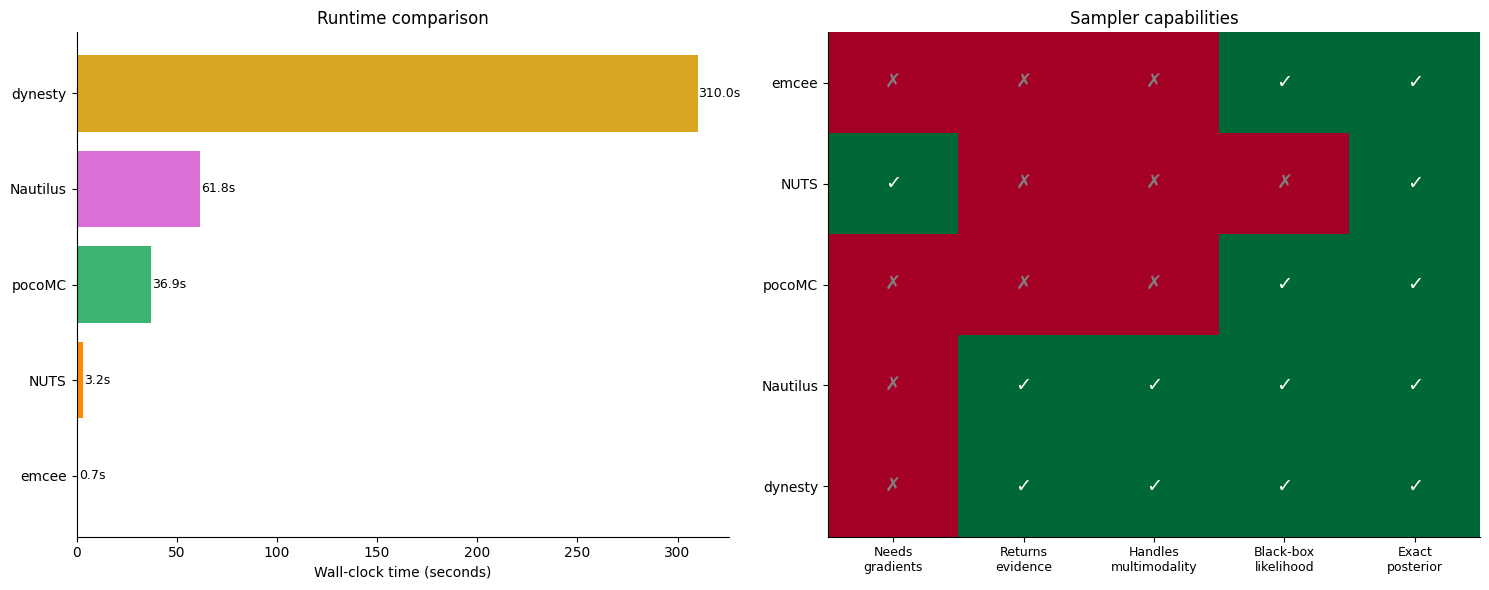

In [83]:
# --- Comparison dashboard ---
sampler_names = ['emcee', 'NUTS', 'pocoMC', 'Nautilus', 'dynesty']
rt_keys = ['emcee', 'nuts', 'pocomc', 'nautilus', 'dynesty']
times = [runtimes.get(k, np.nan) for k in rt_keys]

# Properties matrix (True/False)
#                       emcee  NUTS  pocoMC Naut   dyn   SVI
needs_gradient   = [    False, True, False, False, False ]
gives_evidence   = [    False, False,False, True,  True]
handles_bimodal  = [    False, False,False, True, True]
black_box_ok     = [    True,  False,True,  True,  True]
exact_posterior  = [    True,  True, True,  True,  True]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Runtime bar chart ---
colors = ['steelblue', 'darkorange', 'mediumseagreen', 'orchid', 'goldenrod', 'slategray']
bars = axes[0].barh(sampler_names, times, color=colors)
axes[0].set_xlabel('Wall-clock time (seconds)')
axes[0].set_title('Runtime comparison')
for bar, t in zip(bars, times):
    if not np.isnan(t):
        axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{t:.1f}s', va='center', fontsize=9)

# --- Right: Feature matrix ---
features = np.array([needs_gradient, gives_evidence, handles_bimodal,
                     black_box_ok, exact_posterior]).T
feature_labels = ['Needs\ngradients', 'Returns\nevidence', 'Handles\nmultimodality',
                  'Black-box\nlikelihood', 'Exact\nposterior']
im = axes[1].imshow(features, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(feature_labels)))
axes[1].set_xticklabels(feature_labels, fontsize=9)
axes[1].set_yticks(range(len(sampler_names)))
axes[1].set_yticklabels(sampler_names)
axes[1].set_title('Sampler capabilities')
for i in range(len(sampler_names)):
    for j in range(len(feature_labels)):
        axes[1].text(j, i, '✓' if features[i, j] else '✗',
                     ha='center', va='center', fontsize=14,
                     color='white' if features[i, j] else 'gray')

plt.tight_layout()
plt.show()


**NOTE** nautilus might not handle multimodality in complex cases or when the modes are well separated

---
## Summary 

### Quick-reference table

| Sampler | Mechanism | Gradients? | Evidence? | Multimodal? | Exact? | Sweet spot |
|---------|-----------|:----------:|:---------:|:-----------:|:------:|------------|
| **emcee** | Ensemble stretch moves | No | No | No | Yes | ≤ ~10 params, smooth unimodal posteriors |
| **NUTS** | Hamiltonian Monte Carlo | **Yes** | No | No | Yes | 10–1000+ params, differentiable models |
| **pocoMC** | Preconditioned MC + normalizing flows | No | No | Partial | Yes | Curved/banana posteriors, black-box likelihoods |
| **Nautilus** | Neural importance sampling (nested) | No | **Yes** | Partial | Yes | Model comparison, moderate dimensions |
| **dynesty** | Bounding ellipsoids (nested) | No | **Yes** | **Yes** | Yes | General-purpose nested sampling, dynamic allocation |


### Key takeaways 

1. **emcee is easy but limited** — great for quick exploration, but its random-walk proposals degrade as dimensionality or correlation increases (Level 1 vs Level 2 comparison).
2. **NUTS exploits gradients** — when available, gradient information yields orders-of-magnitude better ESS/sec (head-to-head comparison cell).
3. **pocoMC adapts to geometry** — normalizing flows learn the posterior shape, handling curved or banana-shaped distributions that would require manual reparameterisation for other samplers.
4. **Nested samplers give you evidence for free** — Nautilus and dynesty compute log Z as a by-product, enabling principled model comparison (Bayes factor in Level 4).
5. **dynesty is the general-purpose workhorse** — dynamic nested sampling allocates resolution adaptively; useful across a wide range of problems.
6. **MCMC gets trapped in one mode** — the emcee failure demo shows walkers cannot cross the probability barrier between symmetric modes; nested samplers handle this via systematic contour shrinkage.

